# Sintonia do PID do CSTR por PSO: nominal vs. robusta

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/guilhermemachadogm26-sys/controle-pid/blob/main/pso/pso_sintonia_pid.ipynb)

Estudo complementar ao notebook principal (`cstr_pid_vs_ia.ipynb`). A pergunta: **um PID bem sintonizado por otimização resolve os problemas do PID de referência?**

O estudo tem três etapas:

1. **PSO nominal**: o *Particle Swarm Optimization* busca Kp, Ki e Kd minimizando o erro no modelo nominal do CSTR, sem ruído.
2. **Teste de robustez**: os ganhos encontrados são avaliados em plantas com erro de modelo (UA, k0 ±20 %; ΔHr, q ±10 %) e com ruído de medição.
3. **PSO robusto**: o filtro da derivada entra como 4ª variável, e o custo passa a ser a média sobre 30 plantas incertas com ruído. A avaliação final usa 200 plantas **novas**.

O notebook é independente e roda sem GPU em poucos minutos.

## Módulos base
Iguais aos do notebook principal: modelo do CSTR, PID e planta com falhas.

In [1]:
%%writefile cstr_model.py
"""
Modelo de CSTR nao-isotermico (reacao exotermica irreversivel A -> B).
Parametros classicos de benchmark de controle de processos (mesma
familia usada em livros-texto de controle de processos quimicos),
que exibe nao-linearidade forte e multiplicidade de estados
estacionarios - cenario interessante para comparar controladores
lineares (PID) com agentes que aprendem politicas nao-lineares.
"""
import numpy as np

class CSTR:
    def __init__(self):
        # Parametros do processo (unidades: min, L, mol, K, J)
        self.q = 100.0        # vazao volumetrica [L/min]
        self.V = 100.0        # volume do reator [L]
        self.rho = 1000.0     # densidade [g/L]
        self.Cp = 0.239       # capacidade termica [J/(g.K)]
        self.dHr = -5.0e4     # entalpia de reacao [J/mol]  (exotermica)
        self.EoverR = 8750.0  # E/R [K]
        self.k0 = 7.2e10      # fator pre-exponencial [1/min]
        self.UA = 5.0e4       # coef. global x area de troca [J/(min.K)]
        self.Caf = 1.0        # concentracao de alimentacao [mol/L]
        self.Tf = 350.0       # temperatura de alimentacao [K]

        # Faixa fisica da variavel manipulada (temperatura do fluido
        # de resfriamento na camisa)
        self.Tc_min = 280.0
        self.Tc_max = 350.0

    def k(self, T):
        return self.k0 * np.exp(-self.EoverR / T)

    def derivs(self, state, Tc):
        Ca, T = state
        Ca = max(Ca, 1e-9)  # positividade (concentracao nao pode ser negativa)
        rate = self.k(T) * Ca
        dCadt = (self.q / self.V) * (self.Caf - Ca) - rate
        dTdt = ((self.q / self.V) * (self.Tf - T)
                + (-self.dHr) / (self.rho * self.Cp) * rate
                + (self.UA) / (self.V * self.rho * self.Cp) * (Tc - T))
        return np.array([dCadt, dTdt])

    def step(self, state, Tc, dt, n_sub=10):
        """Integracao por Runge-Kutta 4 com sub-passos para estabilidade."""
        h = dt / n_sub
        s = np.array(state, dtype=float)
        for _ in range(n_sub):
            k1 = self.derivs(s, Tc)
            k2 = self.derivs(s + h/2*k1, Tc)
            k3 = self.derivs(s + h/2*k2, Tc)
            k4 = self.derivs(s + h*k3, Tc)
            s = s + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
            s[0] = max(s[0], 1e-9)
        return s

    def steady_state_near(self, Tc, Ca0=0.5, T0=350.0, dt=0.01, n_steps=20000):
        """Roda o modelo ate convergir, para achar um estado estacionario
        proximo ao chute inicial dado (util pela multiplicidade de
        estados estacionarios deste sistema)."""
        s = np.array([Ca0, T0], dtype=float)
        for _ in range(n_steps):
            s = self.step(s, Tc, dt, n_sub=1)
        return s

Writing cstr_model.py


In [2]:
%%writefile pid_controller.py
"""PID discreto classico, com anti-windup por clamping e filtro na derivada."""
import numpy as np

class PID:
    def __init__(self, Kp, Ki, Kd, dt, u_min=-1.0, u_max=1.0, d_filter=0.1):
        self.Kp, self.Ki, self.Kd = Kp, Ki, Kd
        self.dt = dt
        self.u_min, self.u_max = u_min, u_max
        self.d_filter = d_filter
        self.reset()

    def reset(self):
        self.integral = 0.0
        self.prev_error = None
        self.prev_deriv = 0.0

    def compute(self, setpoint, measurement):
        error = setpoint - measurement
        deriv = 0.0 if self.prev_error is None else (error - self.prev_error) / self.dt
        deriv = self.d_filter * deriv + (1 - self.d_filter) * self.prev_deriv
        self.prev_deriv = deriv

        u_unclamped = self.Kp * error + self.Ki * self.integral + self.Kd * deriv
        u = np.clip(u_unclamped, self.u_min, self.u_max)

        # anti-windup: só integra se não estiver saturado (ou se ajudar a sair da saturação)
        if u == u_unclamped or (u == self.u_max and error < 0) or (u == self.u_min and error > 0):
            self.integral += error * self.dt

        self.prev_error = error
        return u

Writing pid_controller.py


In [3]:
%%writefile plant_with_faults.py
"""
Extensao do modelo do CSTR (cstr_model.py) que permite injetar
perturbacoes e falhas ao longo da simulacao, para testar um
supervisor (humano, regras ou LLM) em cima do controle PID/MPC.

Cenarios implementados:
  1. Degrau na temperatura de alimentacao (Tf)          -> disturbio termico
  2. Degrau na concentracao de alimentacao (Caf)         -> disturbio de carga reacional
  3. Setpoint agressivo que satura o atuador (Tc)        -> limite fisico
  4. Falha de sensor: leitura de temperatura com vies     -> instrumentacao com defeito
"""
import numpy as np
from cstr_model import CSTR

class FaultyCSTRSimulation:
    def __init__(self, dt=0.05, total_minutes=25.0, seed=0):
        self.plant = CSTR()
        self.dt = dt
        self.n_steps = int(total_minutes / dt)
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self, Ca0=0.5, T0=350.0):
        self.state = np.array([Ca0, T0], dtype=float)
        self.t = 0
        self.sensor_bias = 0.0
        self.Tc_prev = (self.plant.Tc_min + self.plant.Tc_max) / 2.0
        self.max_dTc_per_step = 5.0  # mesma taxa maxima de variacao usada no CSTREnv
        self.history = {"t": [], "T_true": [], "T_sensor": [], "Ca": [],
                         "Tc": [], "setpoint": [], "Tf": [], "Caf": []}
        return self.state

    def apply_disturbance(self, scenario, k):
        """Ajusta parametros da planta conforme o cenario e o passo atual k."""
        t_min = k * self.dt
        if scenario == "feed_temperature":
            self.plant.Tf = 315.0 if t_min >= 8.0 else 300.0
        elif scenario == "feed_concentration":
            self.plant.Caf = 1.3 if t_min >= 8.0 else 1.0
        elif scenario == "actuator_saturation":
            pass  # o disturbio aqui eh o setpoint agressivo, tratado no run_experiment
        elif scenario == "sensor_fault":
            self.sensor_bias = 10.0 if t_min >= 8.0 else 0.0

    def sensed_temperature(self, T_true):
        return T_true + self.sensor_bias

    def action_to_Tc(self, action_norm):
        """Converte uma acao normalizada em [-1, 1] para Tc fisico,
        respeitando o limite de taxa de variacao do atuador - MESMA
        convencao usada em cstr_env.py, para manter os controladores
        (PID, MPC) compativeis com os ganhos ja ajustados no resto do
        projeto."""
        Tc_center = (self.plant.Tc_min + self.plant.Tc_max) / 2.0
        Tc_half_range = (self.plant.Tc_max - self.plant.Tc_min) / 2.0
        Tc_target = Tc_center + np.clip(action_norm, -1.0, 1.0) * Tc_half_range
        dTc = np.clip(Tc_target - self.Tc_prev, -self.max_dTc_per_step, self.max_dTc_per_step)
        Tc = np.clip(self.Tc_prev + dTc, self.plant.Tc_min, self.plant.Tc_max)
        self.Tc_prev = Tc
        return Tc

    def step(self, Tc):
        self.state = self.plant.step(self.state, Tc, self.dt)
        return self.state

    def log(self, k, setpoint, Tc):
        Ca, T_true = self.state
        T_sensor = self.sensed_temperature(T_true)
        self.history["t"].append((k+1) * self.dt)
        self.history["T_true"].append(T_true)
        self.history["T_sensor"].append(T_sensor)
        self.history["Ca"].append(Ca)
        self.history["Tc"].append(Tc)
        self.history["setpoint"].append(setpoint)
        self.history["Tf"].append(self.plant.Tf)
        self.history["Caf"].append(self.plant.Caf)

    def as_arrays(self):
        return {k: np.array(v) for k, v in self.history.items()}

Writing plant_with_faults.py


## Simulação vetorizada

`batch_sim.py` reproduz **exatamente** a mesma lógica dos três módulos acima, só que roda centenas de simulações em paralelo com NumPy. A diferença para a simulação original é de 0,0 K em todos os casos testados. É isso que torna o PSO robusto viável: o enxame inteiro é avaliado em 30 plantas numa única chamada.

In [4]:
%%writefile batch_sim.py
"""
Simulacao VETORIZADA do CSTR + PID: roda muitas simulacoes ao mesmo
tempo (uma por "linha"), com numpy. Cada linha pode ter ganhos de PID,
parametros de planta, setpoint e ruido diferentes.

Reproduz exatamente a mesma logica de:
  - cstr_model.py        (EDOs e RK4 com 10 sub-passos)
  - pid_controller.py    (PID com anti-windup por clamping e filtro na derivada)
  - plant_with_faults.py (atuador com limite de taxa, cenario feed_temperature)
So que em paralelo -> o PSO robusto avalia o enxame inteiro, em
dezenas de plantas, numa unica chamada (centenas de vezes mais rapido
que rodar uma simulacao por vez em Python).
"""
import numpy as np
from cstr_model import CSTR

NOMINAL = CSTR()
PARAM_NAMES = ["q", "V", "rho", "Cp", "dHr", "EoverR", "k0", "UA", "Caf", "Tf"]


def simulate_batch(Kp, Ki, Kd, d_filter, setpoint, param_mult=None, minutes=15.0,
                   scenario=None, noise=None, dt=0.05, T0=350.0, Ca0=0.5,
                   T_runaway=600.0, u_min=-1.0, u_max=1.0):
    """Todos os argumentos por-linha sao arrays de mesmo tamanho N (ou escalares).
    param_mult: dict {nome_parametro: array N de multiplicadores}.
    noise: array [N, n_steps] com o ruido somado a medicao (ou None).
    Retorna dict com T_true [N, n_steps], Tc [N, n_steps], diverged [N]."""
    n_steps = int(minutes / dt)
    Kp, Ki, Kd, d_filter, setpoint = np.broadcast_arrays(
        *[np.atleast_1d(np.asarray(x, dtype=float)) for x in (Kp, Ki, Kd, d_filter, setpoint)])
    N = Kp.shape[0]
    P = {name: np.full(N, float(getattr(NOMINAL, name))) for name in PARAM_NAMES}
    for name, mult in (param_mult or {}).items():
        P[name] = P[name] * np.broadcast_to(np.asarray(mult, dtype=float), (N,))
    Tf_base = P["Tf"].copy()

    Ca = np.full(N, Ca0); T = np.full(N, T0)
    integral = np.zeros(N); prev_err = np.zeros(N); prev_deriv = np.zeros(N)
    Tc_min, Tc_max = NOMINAL.Tc_min, NOMINAL.Tc_max
    Tc_center, Tc_half = (Tc_min + Tc_max) / 2, (Tc_max - Tc_min) / 2
    Tc_prev = np.full(N, Tc_center)
    alive = np.ones(N, dtype=bool)
    T_log = np.empty((N, n_steps)); Tc_log = np.empty((N, n_steps))

    n_sub = 10
    h = dt / n_sub

    def derivs(Ca, T, Tc, Tf):
        Ca = np.maximum(Ca, 1e-9)
        rate = P["k0"] * np.exp(-P["EoverR"] / T) * Ca
        dCa = (P["q"] / P["V"]) * (P["Caf"] - Ca) - rate
        dT = ((P["q"] / P["V"]) * (Tf - T)
              + (-P["dHr"]) / (P["rho"] * P["Cp"]) * rate
              + P["UA"] / (P["V"] * P["rho"] * P["Cp"]) * (Tc - T))
        return dCa, dT

    with np.errstate(over="ignore", invalid="ignore"):
        for k in range(n_steps):
            t_min = k * dt
            if scenario == "feed_temperature":
                Tf = np.full(N, 315.0 if t_min >= 8.0 else 300.0)
            else:
                Tf = Tf_base

            T_meas = T if noise is None else T + noise[:, k]

            # ---- PID (mesma logica de pid_controller.py) ----
            err = setpoint - T_meas
            deriv = np.zeros(N) if k == 0 else (err - prev_err) / dt
            deriv = d_filter * deriv + (1 - d_filter) * prev_deriv
            prev_deriv = deriv
            u_un = Kp * err + Ki * integral + Kd * deriv
            u = np.clip(u_un, u_min, u_max)
            integrate = (u == u_un) | ((u == u_max) & (err < 0)) | ((u == u_min) & (err > 0))
            integral = integral + np.where(integrate, err * dt, 0.0)
            prev_err = err

            # ---- atuador (mesma logica de plant_with_faults.action_to_Tc) ----
            Tc_target = Tc_center + np.clip(u, -1.0, 1.0) * Tc_half
            dTc = np.clip(Tc_target - Tc_prev, -5.0, 5.0)
            Tc = np.clip(Tc_prev + dTc, Tc_min, Tc_max)
            Tc_prev = Tc

            # ---- planta: RK4 com sub-passos (mesma logica de cstr_model.step) ----
            ca, tt = Ca.copy(), T.copy()
            for _ in range(n_sub):
                k1a, k1t = derivs(ca, tt, Tc, Tf)
                k2a, k2t = derivs(ca + h/2*k1a, tt + h/2*k1t, Tc, Tf)
                k3a, k3t = derivs(ca + h/2*k2a, tt + h/2*k2t, Tc, Tf)
                k4a, k4t = derivs(ca + h*k3a, tt + h*k3t, Tc, Tf)
                ca = ca + (h/6)*(k1a + 2*k2a + 2*k3a + k4a)
                tt = tt + (h/6)*(k1t + 2*k2t + 2*k3t + k4t)
                ca = np.maximum(ca, 1e-9)

            died = alive & (~np.isfinite(tt) | (tt > T_runaway))
            alive &= ~died
            # linhas que divergiram ficam congeladas (evita overflow)
            Ca = np.where(alive, ca, Ca); T = np.where(alive, tt, T)
            T_log[:, k] = T; Tc_log[:, k] = Tc

    return {"T_true": T_log, "Tc": Tc_log, "diverged": ~alive, "dt": dt,
            "t": (np.arange(n_steps) + 1) * dt}


def row_metrics(res, setpoint):
    """IAE, esforco e overshoot por linha (com T_true apos cada passo, como no log original)."""
    setpoint = np.broadcast_to(np.asarray(setpoint, dtype=float), res["diverged"].shape)[:, None]
    T = res["T_true"]; dt = res["dt"]
    iae = np.sum(np.abs(setpoint - T), axis=1) * dt
    effort = np.sum(np.abs(np.diff(res["Tc"], axis=1)), axis=1)
    sp = setpoint[:, 0]
    over = np.where(sp >= 350.0, np.maximum(0, T.max(axis=1) - sp), np.maximum(0, sp - T.min(axis=1)))
    iae = np.where(res["diverged"], np.nan, iae)
    over = np.where(res["diverged"], np.nan, over)
    return iae, effort, over


Writing batch_sim.py


## Etapa 1: PSO no modelo nominal

Cada partícula é um conjunto (Kp, Ki, Kd), com a busca em escala log10. O custo é a média, nos setpoints de 345, 360 e 375 K, de IAE + 0,02·esforço + 0,05·overshoot². A penalidade de overshoot é essencial: sem ela, o PSO encontra ganhos com IAE baixo mas overshoot de ~70 K, o que é inaceitável num reator exotérmico.

In [5]:
%%writefile pso_tune_pid.py
"""
Sintonia do PID do CSTR por PSO (Particle Swarm Optimization).

Ideia: cada particula do enxame e um conjunto de ganhos (Kp, Ki, Kd).
Para avaliar uma particula, simulamos o CSTR com um PID usando esses ganhos
em varios setpoints e somamos o erro (IAE) + uma pequena penalidade de
esforco do atuador. O PSO procura os ganhos que minimizam esse custo.

Depois comparamos:
  - PID atual do projeto (Kp=0.0006, Ki=0.2, Kd=0.16)
  - PID sintonizado pelo PSO
nos setpoints usados na sintonia E nos cenarios de falha de
plant_with_faults.py (que o PSO NAO viu -> teste de generalizacao).

Usa os mesmos arquivos do projeto: cstr_model.py, pid_controller.py,
plant_with_faults.py (mesma convencao de atuador: acao em [-1, 1],
limite de taxa de 5 K/passo, Tc em [280, 350] K).
"""
import time
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from plant_with_faults import FaultyCSTRSimulation
from pid_controller import PID

# ------------------------- configuracao -------------------------
DT = 0.05
PID_ATUAL = dict(Kp=0.0006, Ki=0.2, Kd=0.16)

# cenarios usados na SINTONIA (degrau de setpoint a partir de T0 = 350 K)
TUNE_SETPOINTS = [345.0, 360.0, 375.0]
TUNE_MINUTES = 15.0

# cenarios de TESTE com falha (o PSO nao ve estes durante a sintonia)
FAULT_SCENARIOS = ["feed_temperature", "feed_concentration", "sensor_fault"]
FAULT_SETPOINT = 360.0
FAULT_MINUTES = 25.0

# espaco de busca em escala log10 (ganhos variam em ordens de grandeza)
LOG_BOUNDS = np.array([[-5.0, 0.0],    # Kp  : 1e-5 .. 1
                       [-3.0, 1.0],    # Ki  : 1e-3 .. 10
                       [-3.0, 1.0]])   # Kd  : 1e-3 .. 10

# hiperparametros do PSO
N_PARTICLES = 20
N_ITER = 30
W_START, W_END = 0.9, 0.4   # inercia decrescente (exploracao -> refinamento)
C1, C2 = 1.5, 1.5           # peso cognitivo (melhor da particula) e social (melhor do enxame)
SEED_WITH_CURRENT = True    # uma particula comeca nos ganhos atuais (pratica comum)
EFFORT_WEIGHT = 0.02        # peso da penalidade de esforco do atuador no custo
OVERSHOOT_WEIGHT = 0.05     # penaliza overshoot^2 [K^2]: reator exotermico nao pode "passar muito"
                            # do setpoint (risco de disparo termico). Sem isso o PSO acha ganhos
                            # agressivos, com IAE baixo mas overshoot de ~70 K.
SEED = 0
# -----------------------------------------------------------------


def simulate_pid(gains, setpoint, minutes, scenario=None):
    """Simula o CSTR com PID. scenario=None -> so degrau de setpoint."""
    sim = FaultyCSTRSimulation(dt=DT, total_minutes=minutes)
    sim.reset()
    pid = PID(**gains, dt=DT)
    for k in range(sim.n_steps):
        if scenario is not None:
            sim.apply_disturbance(scenario, k)
        T_meas = sim.sensed_temperature(sim.state[1])
        a = pid.compute(setpoint, T_meas)
        Tc = sim.action_to_Tc(a)
        sim.step(Tc)
        sim.log(k, setpoint, Tc)
        if not np.isfinite(sim.state[1]) or sim.state[1] > 600:
            return None  # simulacao divergiu
    return sim.as_arrays()


def metrics(arr, setpoint, t_fault=None, tol=0.02):
    e = setpoint - arr["T_true"]
    T, t = arr["T_true"], arr["t"]
    band = tol * abs(setpoint)
    within = np.abs(T - setpoint) <= band
    # tempo de acomodacao: primeiro instante a partir do qual fica sempre na faixa
    outside = np.where(~within)[0]
    if len(outside) == 0:
        settle = t[0]
    elif outside[-1] == len(t) - 1:
        settle = np.nan
    else:
        settle = t[outside[-1] + 1]
    out = {
        "ISE": np.sum(e**2) * DT,
        "IAE": np.sum(np.abs(e)) * DT,
        "Overshoot [K]": max(0.0, T.max() - setpoint) if setpoint >= T[0] else max(0.0, setpoint - T.min()),
        "Acomod. [min]": settle,
        "Esforco [K]": np.sum(np.abs(np.diff(arr["Tc"]))),
    }
    if t_fault is not None:
        out["IAE pos-falha"] = np.sum(np.abs(e[t >= t_fault])) * DT
    return out


def cost(log_gains):
    """Custo de uma particula: media, nos setpoints de sintonia, de
    IAE + penalidade de esforco (atuador 'tremendo') + penalidade de overshoot."""
    Kp, Ki, Kd = 10.0 ** np.asarray(log_gains)
    gains = dict(Kp=Kp, Ki=Ki, Kd=Kd)
    total = 0.0
    for sp in TUNE_SETPOINTS:
        arr = simulate_pid(gains, sp, TUNE_MINUTES)
        if arr is None:
            return 1e6
        e = sp - arr["T_true"]
        iae = np.sum(np.abs(e)) * DT
        effort = np.sum(np.abs(np.diff(arr["Tc"])))
        T = arr["T_true"]
        overshoot = max(0.0, T.max() - sp) if sp >= 350.0 else max(0.0, sp - T.min())
        total += iae + EFFORT_WEIGHT * effort + OVERSHOOT_WEIGHT * overshoot**2
    return total / len(TUNE_SETPOINTS)


def pso(cost_fn, bounds, n_particles, n_iter, seed=0, init_points=()):
    rng = np.random.default_rng(seed)
    dim = len(bounds)
    lo, hi = bounds[:, 0], bounds[:, 1]
    v_max = 0.2 * (hi - lo)

    x = lo + rng.random((n_particles, dim)) * (hi - lo)
    for i, p in enumerate(init_points):
        x[i] = np.clip(p, lo, hi)
    v = rng.uniform(-v_max, v_max, (n_particles, dim))

    f = np.array([cost_fn(xi) for xi in x])
    pbest, pbest_f = x.copy(), f.copy()
    g = np.argmin(f)
    gbest, gbest_f = x[g].copy(), f[g]

    history = [(gbest_f, f.mean())]
    swarm_history = [x.copy()]
    for it in range(n_iter):
        w = W_START - (W_START - W_END) * it / max(1, n_iter - 1)
        r1, r2 = rng.random((n_particles, dim)), rng.random((n_particles, dim))
        v = w * v + C1 * r1 * (pbest - x) + C2 * r2 * (gbest - x)
        v = np.clip(v, -v_max, v_max)
        x = np.clip(x + v, lo, hi)

        f = np.array([cost_fn(xi) for xi in x])
        better = f < pbest_f
        pbest[better], pbest_f[better] = x[better], f[better]
        g = np.argmin(pbest_f)
        if pbest_f[g] < gbest_f:
            gbest, gbest_f = pbest[g].copy(), pbest_f[g]

        valid = f[f < 1e5]
        history.append((gbest_f, valid.mean() if len(valid) else np.nan))
        swarm_history.append(x.copy())
        Kp, Ki, Kd = 10.0 ** gbest
        print(f"Iteracao {it+1:3d}/{n_iter} | melhor custo = {gbest_f:8.3f} | "
              f"Kp={Kp:.2e} Ki={Ki:.3f} Kd={Kd:.3f}", flush=True)
    return gbest, gbest_f, np.array(history), swarm_history


if __name__ == "__main__":
    init = [np.log10([PID_ATUAL["Kp"], PID_ATUAL["Ki"], PID_ATUAL["Kd"]])] if SEED_WITH_CURRENT else []
    print(f"Custo do PID atual: {cost(np.log10(list(PID_ATUAL.values()))):.3f}\n")

    t0 = time.time()
    best_log, best_f, hist, swarm = pso(cost, LOG_BOUNDS, N_PARTICLES, N_ITER, seed=SEED, init_points=init)
    Kp, Ki, Kd = 10.0 ** best_log
    PID_PSO = dict(Kp=float(Kp), Ki=float(Ki), Kd=float(Kd))
    print(f"\nPSO terminou em {time.time()-t0:.1f} s")
    print(f"Ganhos PSO: Kp={Kp:.6f}  Ki={Ki:.4f}  Kd={Kd:.4f}  (custo {best_f:.3f})")
    np.save("pso_pid_gains.npy", np.array([Kp, Ki, Kd]))

    controllers = {"PID atual": PID_ATUAL, "PID-PSO": PID_PSO}

    # ---------------- 1) setpoints usados na sintonia ----------------
    print("\n=== Degraus de setpoint (cenarios da sintonia) ===")
    print(f"{'Setpoint':>8} | {'Controlador':>10} | {'ISE':>9} | {'IAE':>8} | {'Overshoot':>9} | {'Acomod.':>8} | {'Esforco':>8}")
    print("-" * 80)
    sp_runs = {}
    for sp in TUNE_SETPOINTS:
        for name, gains in controllers.items():
            arr = simulate_pid(gains, sp, TUNE_MINUTES)
            sp_runs[(sp, name)] = arr
            if arr is None:
                print(f"{sp:8.0f} | {name:>10} | DIVERGIU (disparo termico)"); continue
            m = metrics(arr, sp)
            print(f"{sp:8.0f} | {name:>10} | {m['ISE']:9.1f} | {m['IAE']:8.2f} | {m['Overshoot [K]']:9.2f} | "
                  f"{m['Acomod. [min]']:8.2f} | {m['Esforco [K]']:8.1f}")

    # ---------------- 2) cenarios de falha (nao vistos) ----------------
    print(f"\n=== Cenarios de falha (setpoint {FAULT_SETPOINT} K, falha em t = 8 min; NAO usados na sintonia) ===")
    print(f"{'Cenario':>20} | {'Controlador':>10} | {'ISE':>9} | {'IAE':>8} | {'IAE pos-falha':>13} | {'Esforco':>8}")
    print("-" * 82)
    fault_runs = {}
    for sc in FAULT_SCENARIOS:
        for name, gains in controllers.items():
            arr = simulate_pid(gains, FAULT_SETPOINT, FAULT_MINUTES, scenario=sc)
            fault_runs[(sc, name)] = arr
            if arr is None:
                print(f"{sc:>20} | {name:>10} | DIVERGIU (disparo termico)"); continue
            m = metrics(arr, FAULT_SETPOINT, t_fault=8.0)
            print(f"{sc:>20} | {name:>10} | {m['ISE']:9.1f} | {m['IAE']:8.2f} | {m['IAE pos-falha']:13.2f} | {m['Esforco [K]']:8.1f}")

    # --------------------------- graficos ---------------------------
    styles = {"PID atual": dict(lw=2), "PID-PSO": dict(lw=2, ls="--")}

    # (a) convergencia do PSO + enxame no plano Ki x Kd
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    ax[0].plot(hist[:, 0], lw=2, label="Melhor custo (gbest)")
    ax[0].plot(hist[:, 1], lw=1, alpha=0.7, label="Custo medio do enxame")
    ax[0].set_yscale("log"); ax[0].set_xlabel("Iteracao"); ax[0].set_ylabel("Custo")
    ax[0].set_title("Convergencia do PSO"); ax[0].legend()
    for i, s in enumerate(swarm[::max(1, len(swarm)//6)]):
        ax[1].scatter(s[:, 1], s[:, 2], s=12, alpha=0.3 + 0.7 * i / 6, label=f"it {i*max(1, len(swarm)//6)}")
    ax[1].scatter(best_log[1], best_log[2], marker="*", s=250, c="red", label="Melhor")
    ax[1].scatter(*np.log10([PID_ATUAL["Ki"], PID_ATUAL["Kd"]]), marker="X", s=120, c="k", label="PID atual")
    ax[1].set_xlabel("log10(Ki)"); ax[1].set_ylabel("log10(Kd)")
    ax[1].set_title("Enxame ao longo das iteracoes"); ax[1].legend(fontsize=7)
    plt.tight_layout(); plt.savefig("pso_convergencia.png", dpi=150)

    # (b) respostas: setpoints (linha de cima) e falhas (linha de baixo)
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for j, sp in enumerate(TUNE_SETPOINTS):
        for name in controllers:
            arr = sp_runs[(sp, name)]
            if arr is None: continue
            axes[0, j].plot(arr["t"], arr["T_true"], label=name, **styles[name])
        axes[0, j].axhline(sp, color="gray", ls=":", label="Setpoint")
        axes[0, j].set_title(f"Degrau de setpoint: {sp:.0f} K"); axes[0, j].set_ylabel("T [K]")
    for j, sc in enumerate(FAULT_SCENARIOS):
        for name in controllers:
            arr = fault_runs[(sc, name)]
            if arr is None: continue
            axes[1, j].plot(arr["t"], arr["T_true"], label=name, **styles[name])
        if all(fault_runs[(sc, n)] is None for n in controllers):
            axes[1, j].text(0.5, 0.5, "Ambos os PIDs divergem\n(atuador satura em Tc = 280 K:\nfalta capacidade de resfriamento)",
                            ha="center", va="center", transform=axes[1, j].transAxes, fontsize=10)
        axes[1, j].axhline(FAULT_SETPOINT, color="gray", ls=":")
        axes[1, j].axvline(8.0, color="red", alpha=0.3, label="Falha")
        axes[1, j].set_title(f"Falha: {sc}"); axes[1, j].set_ylabel("T real [K]"); axes[1, j].set_xlabel("Tempo [min]")
    axes[0, 0].legend(fontsize=8); axes[1, 0].legend(fontsize=8)
    plt.tight_layout(); plt.savefig("pso_vs_pid_respostas.png", dpi=150)
    print("\nGraficos salvos em pso_convergencia.png e pso_vs_pid_respostas.png")


Writing pso_tune_pid.py


Custo do PID atual: 133.703



Iteracao   1/30 | melhor custo =  133.703 | Kp=6.00e-04 Ki=0.200 Kd=0.160


Iteracao   2/30 | melhor custo =   69.526 | Kp=9.11e-05 Ki=0.353 Kd=0.137


Iteracao   3/30 | melhor custo =   69.526 | Kp=9.11e-05 Ki=0.353 Kd=0.137


Iteracao   4/30 | melhor custo =   69.526 | Kp=9.11e-05 Ki=0.353 Kd=0.137


...

  feed_concentration |  PID atual | DIVERGIU (disparo termico)


  feed_concentration |    PID-PSO | DIVERGIU (disparo termico)


        sensor_fault |  PID atual |    7534.0 |   333.98 |        220.69 |   1099.4


        sensor_fault |    PID-PSO |    3922.6 |   226.10 |        209.45 |    654.3



Graficos salvos em pso_convergencia.png e pso_vs_pid_respostas.png


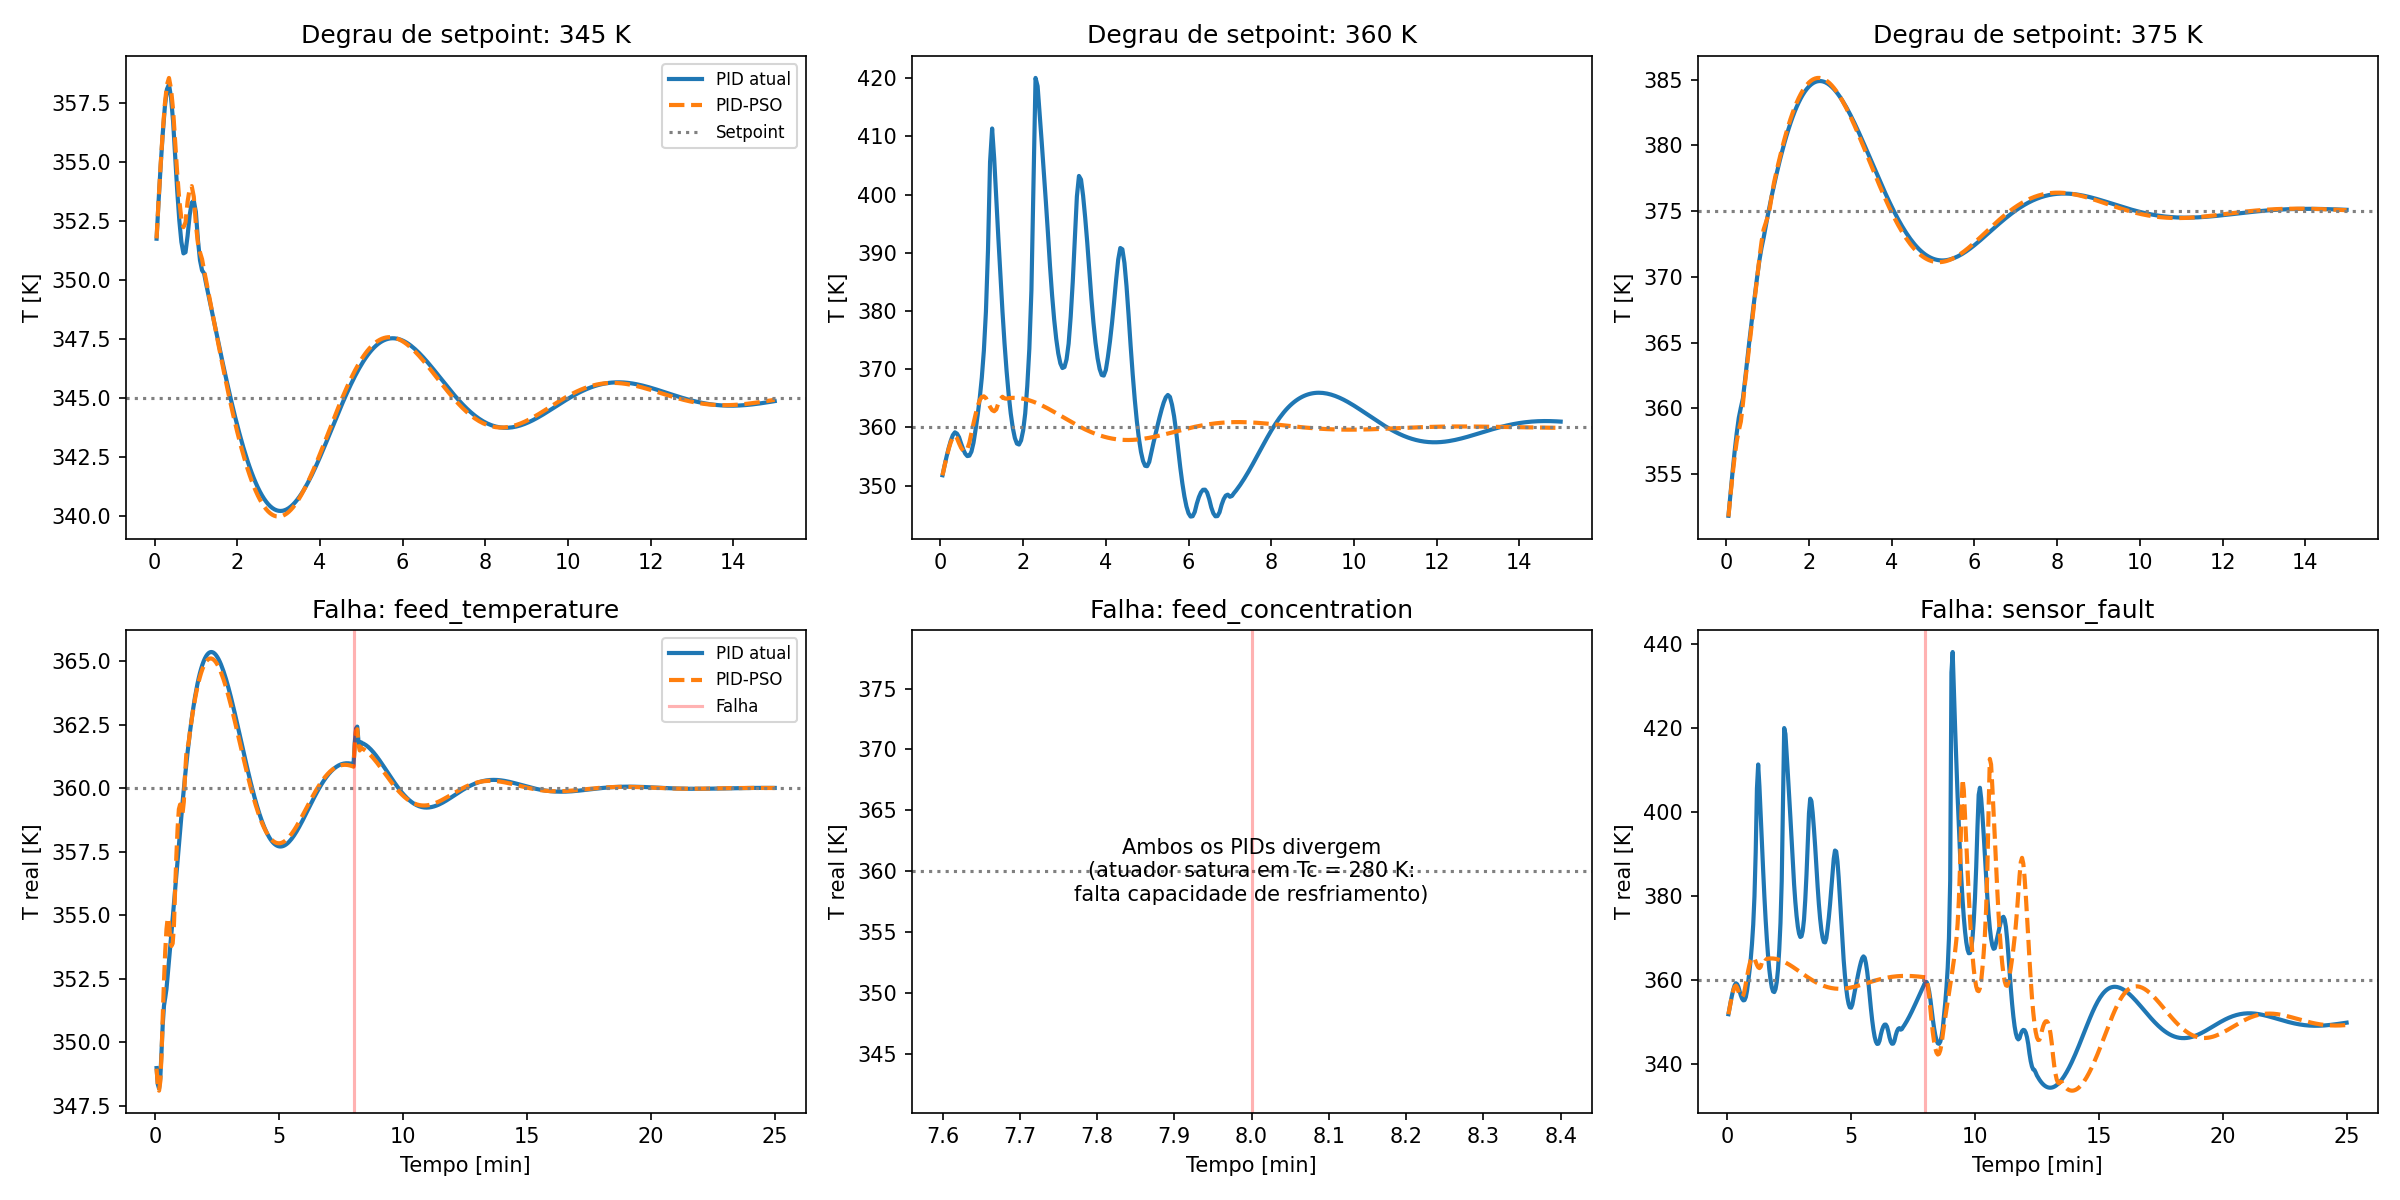

In [6]:
!python pso_tune_pid.py
from IPython.display import Image, display
display(Image('pso_vs_pid_respostas.png'))

## Etapa 2: teste de robustez
Sensibilidade a um parâmetro por vez (±20 %) e Monte Carlo com 100 plantas incertas mais ruído de 0,5 K.

In [7]:
%%writefile robustez_pid_pso.py
"""
Teste de robustez: PID atual vs PID sintonizado por PSO (pso_tune_pid.py).

O PSO sintonizou os ganhos no modelo NOMINAL do CSTR. Na pratica, o
modelo nunca e exato. Aqui verificamos se o ganho de desempenho se
mantem quando a planta real e diferente do modelo:

1) Sensibilidade (um parametro por vez): UA, k0, dHr e q variam de
   -20% a +20% em torno do nominal; os outros ficam fixos.
2) Monte Carlo: N plantas sorteadas com TODOS os parametros incertos
   ao mesmo tempo + ruido gaussiano na medicao de temperatura.

Metricas: IAE, overshoot e taxa de divergencia (disparo termico),
nos degraus de setpoint (345, 360, 375 K) e na falha de temperatura
de alimentacao (feed_temperature).
"""
import time
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from plant_with_faults import FaultyCSTRSimulation
from pid_controller import PID

DT = 0.05
PID_ATUAL = dict(Kp=0.0006, Ki=0.2, Kd=0.16)
try:
    Kp, Ki, Kd = np.load("pso_pid_gains.npy")
    PID_PSO = dict(Kp=float(Kp), Ki=float(Ki), Kd=float(Kd))
except FileNotFoundError:   # ganhos obtidos na execucao de referencia
    PID_PSO = dict(Kp=0.000024, Ki=0.2323, Kd=0.1799)
CONTROLLERS = {"PID atual": PID_ATUAL, "PID-PSO": PID_PSO}

# casos de teste: (nome, setpoint, minutos, cenario de falha)
CASES = [("SP 345 K", 345.0, 15.0, None),
         ("SP 360 K", 360.0, 15.0, None),
         ("SP 375 K", 375.0, 15.0, None),
         ("Falha Tf", 360.0, 25.0, "feed_temperature")]

# parametros incertos e faixa de variacao relativa
PARAMS = {"UA":  0.20,   # coef. de troca termica (incrustacao, vazao na camisa)
          "k0":  0.20,   # fator pre-exponencial (atividade do catalisador / cinetica)
          "dHr": 0.10,   # entalpia de reacao
          "q":   0.10}   # vazao volumetrica
SENS_LEVELS = np.linspace(-0.20, 0.20, 9)
N_MC = 100
NOISE_STD = 0.5           # ruido de medicao [K] no Monte Carlo
SEED = 1
T_RUNAWAY = 600.0         # acima disso consideramos que o reator disparou


def simulate(gains, setpoint, minutes, scenario=None, param_mult=None, noise_std=0.0, rng=None):
    sim = FaultyCSTRSimulation(dt=DT, total_minutes=minutes)
    sim.reset()
    for name, mult in (param_mult or {}).items():
        setattr(sim.plant, name, getattr(sim.plant, name) * mult)
    pid = PID(**gains, dt=DT)
    for k in range(sim.n_steps):
        if scenario is not None:
            sim.apply_disturbance(scenario, k)
        T_meas = sim.sensed_temperature(sim.state[1])
        if noise_std > 0:
            T_meas += rng.normal(0.0, noise_std)
        Tc = sim.action_to_Tc(pid.compute(setpoint, T_meas))
        sim.step(Tc)
        sim.log(k, setpoint, Tc)
        if not np.isfinite(sim.state[1]) or sim.state[1] > T_RUNAWAY:
            return None
    return sim.as_arrays()


def summarize(arr, setpoint):
    if arr is None:
        return dict(IAE=np.nan, OS=np.nan, div=1.0)
    T = arr["T_true"]
    e = setpoint - T
    os_ = max(0.0, T.max() - setpoint) if setpoint >= 350.0 else max(0.0, setpoint - T.min())
    return dict(IAE=np.sum(np.abs(e)) * DT, OS=os_, div=0.0)


if __name__ == "__main__":
    t0 = time.time()
    print(f"PID atual: {PID_ATUAL}\nPID-PSO  : " + ", ".join(f"{k}={v:.6g}" for k, v in PID_PSO.items()) + "\n")

    # ---------------- 1) sensibilidade, um parametro por vez ----------------
    sens = {}   # (param, controlador, caso) -> lista de IAE por nivel
    for p in PARAMS:
        for cname, g in CONTROLLERS.items():
            for case, sp, mins, sc in CASES:
                vals = []
                for lvl in SENS_LEVELS:
                    s = summarize(simulate(g, sp, mins, sc, {p: 1 + lvl}), sp)
                    vals.append(s["IAE"])
                sens[(p, cname, case)] = np.array(vals)
    print(f"Sensibilidade concluida em {time.time()-t0:.0f} s\n")

    print("=== Sensibilidade: IAE no pior caso da faixa +-20% (nan = divergiu em algum nivel) ===")
    print(f"{'Parametro':>9} | {'Caso':>9} | {'PID atual':>10} | {'PID-PSO':>10}")
    print("-" * 48)
    for p in PARAMS:
        for case, *_ in CASES:
            a = sens[(p, "PID atual", case)]; b = sens[(p, "PID-PSO", case)]
            fa = "diverge" if np.isnan(a).any() else f"{a.max():10.1f}"
            fb = "diverge" if np.isnan(b).any() else f"{b.max():10.1f}"
            print(f"{p:>9} | {case:>9} | {fa:>10} | {fb:>10}")

    # ---------------- 2) Monte Carlo ----------------
    rng = np.random.default_rng(SEED)
    samples = [{p: 1 + rng.uniform(-r, r) for p, r in PARAMS.items()} for _ in range(N_MC)]
    mc = {(c, case): [] for c in CONTROLLERS for case, *_ in CASES}
    for i, mult in enumerate(samples):
        for cname, g in CONTROLLERS.items():
            for case, sp, mins, sc in CASES:
                # mesma semente de ruido para os dois controladores (comparacao pareada)
                r = np.random.default_rng(SEED * 10_000 + i)
                mc[(cname, case)].append(summarize(simulate(g, sp, mins, sc, mult, NOISE_STD, r), sp))
    print(f"\nMonte Carlo ({N_MC} plantas, ruido {NOISE_STD} K) concluido em {time.time()-t0:.0f} s total\n")

    print(f"=== Monte Carlo: {N_MC} plantas com UA, k0 +-20%, dHr, q +-10% e ruido de {NOISE_STD} K ===")
    print(f"{'Caso':>9} | {'Controlador':>10} | {'IAE mediana':>11} | {'IAE p90':>8} | {'Overshoot med.':>14} | {'Diverge':>8}")
    print("-" * 75)
    wins = {}
    for case, *_ in CASES:
        for cname in CONTROLLERS:
            r = mc[(cname, case)]
            iae = np.array([x["IAE"] for x in r]); os_ = np.array([x["OS"] for x in r])
            div = np.mean([x["div"] for x in r]) * 100
            ok = ~np.isnan(iae)
            med = np.median(iae[ok]) if ok.any() else np.nan
            p90 = np.percentile(iae[ok], 90) if ok.any() else np.nan
            osm = np.median(os_[ok]) if ok.any() else np.nan
            print(f"{case:>9} | {cname:>10} | {med:11.1f} | {p90:8.1f} | {osm:14.1f} | {div:7.0f}%")
        # comparacao pareada: em quantas plantas o PSO teve IAE menor (divergir = pior)
        a = np.array([x["IAE"] for x in mc[("PID atual", case)]], dtype=float)
        b = np.array([x["IAE"] for x in mc[("PID-PSO", case)]], dtype=float)
        a[np.isnan(a)] = np.inf; b[np.isnan(b)] = np.inf
        wins[case] = 100 * np.mean(b < a)
    print("\nPlantas em que o PID-PSO teve IAE menor que o PID atual (comparacao pareada):")
    for case, w in wins.items():
        print(f"  {case}: {w:.0f}%")

    # --------------------------- graficos ---------------------------
    colors = {"PID atual": "C0", "PID-PSO": "C1"}
    fig, axes = plt.subplots(len(PARAMS), len(CASES), figsize=(16, 12), sharex=True)
    for i, p in enumerate(PARAMS):
        for j, (case, *_) in enumerate(CASES):
            ax = axes[i, j]
            for cname in CONTROLLERS:
                y = sens[(p, cname, case)]
                ax.plot(100 * SENS_LEVELS, y, marker="o", color=colors[cname], ms=4, label=cname,
                        ls="-" if cname == "PID atual" else "--")
                nan = np.isnan(y)
                if nan.any():
                    ax.plot(100 * SENS_LEVELS[nan], np.zeros(nan.sum()), "x", color=colors[cname], ms=10, mew=2)
            ax.set_yscale("log")
            if i == 0: ax.set_title(case)
            if j == 0: ax.set_ylabel(f"IAE  (variando {p})")
            if i == len(PARAMS) - 1: ax.set_xlabel(f"Variacao do parametro [%]")
    axes[0, 0].legend(fontsize=8)
    fig.suptitle("Sensibilidade do IAE a erros de modelo (x no eixo = divergiu)", fontsize=12)
    plt.tight_layout(); plt.savefig("robustez_sensibilidade.png", dpi=150)

    fig, axes = plt.subplots(1, len(CASES), figsize=(16, 4.5))
    for j, (case, *_) in enumerate(CASES):
        data, labels = [], []
        for cname in CONTROLLERS:
            iae = np.array([x["IAE"] for x in mc[(cname, case)]])
            data.append(iae[~np.isnan(iae)])
            div = np.isnan(iae).sum()
            labels.append(f"{cname}\n(divergiu {div}/{N_MC})")
        bp = axes[j].boxplot(data, tick_labels=labels, patch_artist=True, widths=0.5)
        for patch, cname in zip(bp["boxes"], CONTROLLERS):
            patch.set_facecolor(colors[cname]); patch.set_alpha(0.5)
        axes[j].set_yscale("log"); axes[j].set_title(f"{case} - PSO melhor em {wins[case]:.0f}%")
        axes[j].set_ylabel("IAE")
    fig.suptitle(f"Monte Carlo: {N_MC} plantas incertas + ruido de medicao {NOISE_STD} K", fontsize=12)
    plt.tight_layout(); plt.savefig("robustez_montecarlo.png", dpi=150)
    print("\nGraficos salvos em robustez_sensibilidade.png e robustez_montecarlo.png")


Writing robustez_pid_pso.py


PID atual: {'Kp': 0.0006, 'Ki': 0.2, 'Kd': 0.16}
PID-PSO  : Kp=2.37839e-05, Ki=0.232277, Kd=0.179913



Sensibilidade concluida em 18 s

=== Sensibilidade: IAE no pior caso da faixa +-20% (nan = divergiu em algum nivel) ===
Parametro |      Caso |  PID atual |    PID-PSO
------------------------------------------------
       UA |  SP 345 K |      424.8 |      425.3
       UA |  SP 360 K |      301.3 |      298.3
       UA |  SP 375 K |       74.2 |      171.1
       UA |  Falha Tf |       30.3 |       28.8
       k0 |  SP 345 K |      138.4 |      150.7
       k0 |  SP 360 K |      235.3 |      246.8
       k0 |  SP 375 K |      185.1 |      212.4
       k0 |  Falha Tf |       36.5 |       35.3
      dHr |  SP 345 K |    diverge |    diverge
      dHr |  SP 360 K |      328.3 |      325.9
      dHr |  SP 375 K |      191.9 |      199.6
      dHr |  Falha Tf |       35.7 |       35.1
        q |  SP 345 K |      188.3 |      155.3
        q |  SP 360 K |      176.7 |      275.7
        q |  SP 375 K |      196.4 |      200.7
        q |  Falha Tf |      338.7 |       31.3



Monte Carlo (100 plantas, ruido 0.5 K) concluido em 68 s total

=== Monte Carlo: 100 plantas com UA, k0 +-20%, dHr, q +-10% e ruido de 0.5 K ===
     Caso | Controlador | IAE mediana |  IAE p90 | Overshoot med. |  Diverge
---------------------------------------------------------------------------
 SP 345 K |  PID atual |        38.2 |    366.9 |            5.5 |       5%
 SP 345 K |    PID-PSO |        74.8 |    365.1 |            5.9 |       4%
 SP 360 K |  PID atual |       193.8 |    278.9 |           71.0 |       0%
 SP 360 K |    PID-PSO |       218.3 |    285.3 |           71.7 |       0%
 SP 375 K |  PID atual |       161.7 |    217.0 |           54.5 |       0%
 SP 375 K |    PID-PSO |       163.9 |    221.0 |           55.0 |       0%
 Falha Tf |  PID atual |       373.4 |    478.4 |           76.9 |       0%
 Falha Tf |    PID-PSO |       402.9 |    506.5 |           80.0 |       0%

Plantas em que o PID-PSO teve IAE menor que o PID atual (comparacao pareada):
  SP 345 K: 39


Graficos salvos em robustez_sensibilidade.png e robustez_montecarlo.png


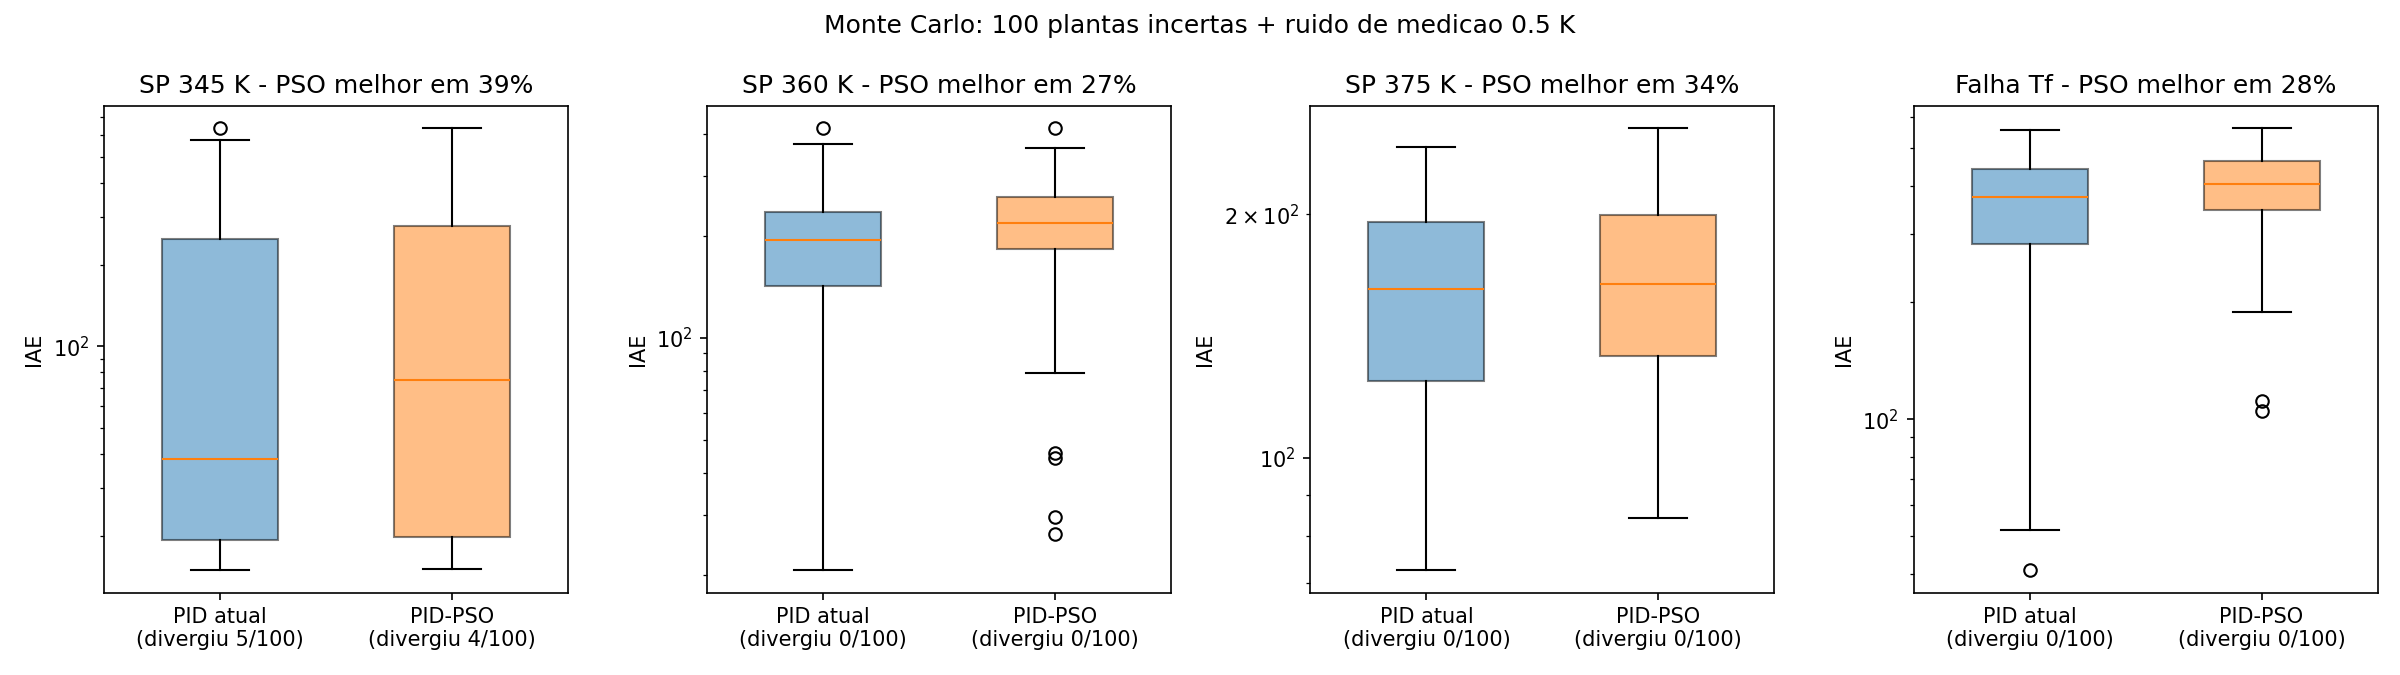

In [8]:
!python robustez_pid_pso.py
display(Image('robustez_montecarlo.png'))

**Resultado:** a melhoria da etapa 1 em 360 K some com erros de ~5 % no modelo. Nesse setpoint os dois PIDs alternam entre acomodar bem e oscilar, e o PSO só achou ganhos em que a planta *nominal* cai no lado bom. E um ruído de apenas 0,5 K faz os dois oscilarem ±40 K, por causa da derivada. Tirar a derivada (Kd = 0) instabiliza o reator, e filtrar mais a derivada remove a sensibilidade ao ruído, mas piora o desempenho sem ruído. Há um compromisso, e nenhuma das duas sintonias o considerou.

## Etapa 3: PSO robusto
4 variáveis (Kp, Ki, Kd, filtro da derivada). O custo é a média sobre 30 plantas incertas com ruído de 0,5 K. A avaliação é feita em 200 plantas novas, em quatro condições.

In [9]:
%%writefile pso_robusto.py
"""
Sintonia ROBUSTA do PID por PSO, e comparacao de 3 sintonias:

  1. PID atual          (Kp=0.0006, Ki=0.2, Kd=0.16, filtro 0.1)
  2. PID-PSO nominal    (pso_tune_pid.py: sintonizado so no modelo nominal, sem ruido)
  3. PID-PSO robusto    (este script)

Diferencas do PSO robusto em relacao ao nominal:
  - 4 variaveis: Kp, Ki, Kd E o filtro da derivada (d_filter). O teste de
    robustez mostrou que o derivativo e essencial (Kd=0 instabiliza), mas
    e ele que amplifica o ruido -> o filtro entra na otimizacao.
  - O custo de cada particula e a MEDIA sobre N_TRAIN plantas sorteadas
    (UA, k0 +-20%; dHr, q +-10%) COM ruido de medicao, e nao so a planta
    nominal. Isso evita o "sobreajuste" ao modelo.

A avaliacao final usa plantas NOVAS (outra semente), nunca vistas pelo PSO.
Usa batch_sim.py (simulacao vetorizada, validada contra plant_with_faults.py).
"""
import time
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from batch_sim import simulate_batch, row_metrics

# ------------------------- configuracao -------------------------
DT = 0.05
PID_ATUAL = dict(Kp=0.0006, Ki=0.2, Kd=0.16, d_filter=0.1)
try:
    _g = np.load("pso_pid_gains.npy")
    PID_PSO_NOM = dict(Kp=float(_g[0]), Ki=float(_g[1]), Kd=float(_g[2]), d_filter=0.1)
except FileNotFoundError:
    PID_PSO_NOM = dict(Kp=2.378e-05, Ki=0.23228, Kd=0.17991, d_filter=0.1)

UNCERTAINTY = {"UA": 0.20, "k0": 0.20, "dHr": 0.10, "q": 0.10}
NOISE_STD = 0.5                      # ruido de medicao [K]
TUNE_SETPOINTS = [345.0, 360.0, 375.0]
TUNE_MINUTES = 15.0

N_TRAIN = 30                         # plantas usadas DENTRO do PSO
N_TEST = 200                         # plantas NOVAS para a avaliacao final
TRAIN_SEED, TEST_SEED = 100, 999

# espaco de busca (log10)
LOG_BOUNDS = np.array([[-5.0, 0.0],   # Kp
                       [-3.0, 1.0],   # Ki
                       [-3.0, 1.0],   # Kd
                       [-2.5, 0.0]])  # d_filter (0.003 .. 1; 1 = sem filtro)
N_PARTICLES, N_ITER = 30, 40
W_START, W_END, C1, C2 = 0.9, 0.4, 1.5, 1.5
EFFORT_WEIGHT, OVERSHOOT_WEIGHT, DIVERGE_COST = 0.02, 0.05, 5000.0
PSO_SEED = 0
# -----------------------------------------------------------------


def sample_plants(n, seed):
    rng = np.random.default_rng(seed)
    return {p: 1 + rng.uniform(-r, r, n) for p, r in UNCERTAINTY.items()}


def make_noise(n_rows, minutes, seed, std):
    return np.random.default_rng(seed).normal(0.0, std, (n_rows, int(minutes / DT)))


# conjunto de treino fixo (numeros aleatorios comuns: todas as particulas
# veem as MESMAS plantas e o MESMO ruido -> comparacao justa entre elas)
TRAIN_PLANTS = sample_plants(N_TRAIN, TRAIN_SEED)
N_SP = len(TUNE_SETPOINTS)
TRAIN_NOISE = make_noise(N_TRAIN * N_SP, TUNE_MINUTES, TRAIN_SEED + 1, NOISE_STD)


def swarm_cost(X):
    """Custo de TODAS as particulas de uma vez. X: [n_particles, 4] em log10."""
    n = X.shape[0]
    G = 10.0 ** X                                     # [n, 4]
    rows = n * N_TRAIN * N_SP                         # particula x planta x setpoint
    rep = lambda v: np.repeat(v, N_TRAIN * N_SP)
    sp = np.tile(np.repeat(TUNE_SETPOINTS, N_TRAIN), n)
    mult = {p: np.tile(np.tile(m, N_SP), n) for p, m in TRAIN_PLANTS.items()}
    noise = np.tile(TRAIN_NOISE, (n, 1))
    res = simulate_batch(rep(G[:, 0]), rep(G[:, 1]), rep(G[:, 2]), rep(G[:, 3]), sp,
                         mult, TUNE_MINUTES, None, noise, DT)
    iae, eff, over = row_metrics(res, sp)
    c = iae + EFFORT_WEIGHT * eff + OVERSHOOT_WEIGHT * over**2
    c = np.where(res["diverged"], DIVERGE_COST, c)
    return c.reshape(n, N_TRAIN * N_SP).mean(axis=1)


def pso(init_points=()):
    rng = np.random.default_rng(PSO_SEED)
    lo, hi = LOG_BOUNDS[:, 0], LOG_BOUNDS[:, 1]
    dim = len(lo); v_max = 0.2 * (hi - lo)
    x = lo + rng.random((N_PARTICLES, dim)) * (hi - lo)
    for i, p in enumerate(init_points):
        x[i] = np.clip(p, lo, hi)
    v = rng.uniform(-v_max, v_max, (N_PARTICLES, dim))
    f = swarm_cost(x)
    pbest, pbest_f = x.copy(), f.copy()
    g = np.argmin(f); gbest, gbest_f = x[g].copy(), f[g]
    hist = [(gbest_f, np.median(f))]
    for it in range(N_ITER):
        w = W_START - (W_START - W_END) * it / max(1, N_ITER - 1)
        r1, r2 = rng.random(x.shape), rng.random(x.shape)
        v = np.clip(w * v + C1 * r1 * (pbest - x) + C2 * r2 * (gbest - x), -v_max, v_max)
        x = np.clip(x + v, lo, hi)
        f = swarm_cost(x)
        better = f < pbest_f
        pbest[better], pbest_f[better] = x[better], f[better]
        g = np.argmin(pbest_f)
        if pbest_f[g] < gbest_f:
            gbest, gbest_f = pbest[g].copy(), pbest_f[g]
        hist.append((gbest_f, np.median(f)))
        Kp, Ki, Kd, df = 10.0 ** gbest
        print(f"Iteracao {it+1:3d}/{N_ITER} | custo medio = {gbest_f:8.2f} | "
              f"Kp={Kp:.2e} Ki={Ki:.3f} Kd={Kd:.3f} filtro={df:.3f}", flush=True)
    return gbest, gbest_f, np.array(hist)


def evaluate(ctrl, sp, minutes, scenario, plants, noise):
    n = len(next(iter(plants.values()))) if plants else noise.shape[0] if noise is not None else 1
    res = simulate_batch(np.full(n, ctrl["Kp"]), ctrl["Ki"], ctrl["Kd"], ctrl["d_filter"],
                         np.full(n, sp), plants, minutes, scenario, noise, DT)
    iae, eff, over = row_metrics(res, sp)
    return iae, over, res


if __name__ == "__main__":
    as_log = lambda c: np.log10([c["Kp"], c["Ki"], c["Kd"], c["d_filter"]])
    print(f"Custo robusto (treino) do PID atual       : {swarm_cost(as_log(PID_ATUAL)[None])[0]:.2f}")
    print(f"Custo robusto (treino) do PID-PSO nominal : {swarm_cost(as_log(PID_PSO_NOM)[None])[0]:.2f}\n")

    t0 = time.time()
    best, best_f, hist = pso(init_points=[as_log(PID_ATUAL), as_log(PID_PSO_NOM)])
    Kp, Ki, Kd, df = 10.0 ** best
    PID_PSO_ROB = dict(Kp=float(Kp), Ki=float(Ki), Kd=float(Kd), d_filter=float(df))
    np.save("pso_robusto_gains.npy", np.array([Kp, Ki, Kd, df]))
    print(f"\nPSO robusto terminou em {time.time()-t0:.0f} s")
    print(f"Ganhos: Kp={Kp:.6f}  Ki={Ki:.4f}  Kd={Kd:.4f}  filtro derivada={df:.4f}\n")

    CTRL = {"PID atual": PID_ATUAL, "PSO nominal": PID_PSO_NOM, "PSO robusto": PID_PSO_ROB}
    CASES = [("SP 345 K", 345.0, 15.0, None), ("SP 360 K", 360.0, 15.0, None),
             ("SP 375 K", 375.0, 15.0, None), ("Falha Tf", 360.0, 25.0, "feed_temperature")]
    test_plants = sample_plants(N_TEST, TEST_SEED)
    CONDITIONS = {
        "A) Planta nominal, sem ruido":                    (None, 0.0, 1),
        "B) Plantas incertas, sem ruido":                  (test_plants, 0.0, N_TEST),
        f"C) Plantas incertas + ruido {NOISE_STD} K":      (test_plants, NOISE_STD, N_TEST),
        "D) Planta nominal + ruido 1.0 K (estresse)":      (None, 1.0, N_TEST),
    }

    results = {}
    for cond, (plants, std, n) in CONDITIONS.items():
        print(f"=== {cond} " + ("" if n == 1 else f"({n} simulacoes por caso) ") + "===")
        print(f"{'Caso':>9} | {'Controlador':>12} | {'IAE mediana':>11} | {'IAE p90':>8} | {'Overshoot med.':>14} | {'Diverge':>7}")
        print("-" * 76)
        for case, sp, mins, sc in CASES:
            noise = make_noise(n, mins, TEST_SEED + 7, std) if std > 0 else None
            for cname, c in CTRL.items():
                iae, over, _ = evaluate(c, sp, mins, sc, plants, noise)
                results[(cond, case, cname)] = iae
                ok = ~np.isnan(iae)
                med = np.median(iae[ok]) if ok.any() else np.nan
                p90 = np.percentile(iae[ok], 90) if ok.any() else np.nan
                osm = np.median(over[ok]) if ok.any() else np.nan
                p90s = "" if n == 1 else f"{p90:8.1f}"
                print(f"{case:>9} | {cname:>12} | {med:11.1f} | {p90s:>8} | {osm:14.1f} | {100*np.mean(~ok):6.0f}%")
        if n > 1:
            print("  PSO robusto com IAE menor que o PID atual (pareado, divergir = pior):")
            for case, *_ in CASES:
                a = np.nan_to_num(results[(cond, case, "PID atual")], nan=np.inf)
                b = np.nan_to_num(results[(cond, case, "PSO robusto")], nan=np.inf)
                print(f"    {case}: {100*np.mean(b < a):.0f}% das plantas")
        print()

    # --------------------------- graficos ---------------------------
    colors = {"PID atual": "C0", "PSO nominal": "C1", "PSO robusto": "C2"}

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(hist[:, 0], lw=2, label="Melhor custo (gbest)")
    ax.plot(hist[:, 1], lw=1, alpha=0.7, label="Mediana do enxame")
    ax.set_yscale("log"); ax.set_xlabel("Iteracao"); ax.set_ylabel("Custo medio em 30 plantas")
    ax.set_title("Convergencia do PSO robusto"); ax.legend()
    plt.tight_layout(); plt.savefig("pso_robusto_convergencia.png", dpi=150)

    conds_mc = [c for c, v in CONDITIONS.items() if v[2] > 1]
    fig, axes = plt.subplots(len(conds_mc), len(CASES), figsize=(17, 4 * len(conds_mc)))
    for i, cond in enumerate(conds_mc):
        for j, (case, *_) in enumerate(CASES):
            ax = axes[i, j]
            data, labels = [], []
            for cname in CTRL:
                v = results[(cond, case, cname)]
                data.append(v[~np.isnan(v)] if (~np.isnan(v)).any() else [np.nan])
                d = np.isnan(v).sum()
                labels.append(cname.replace(" ", "\n") + (f"\n(div. {d})" if d else ""))
            bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, widths=0.55, showfliers=False)
            for patch, cname in zip(bp["boxes"], CTRL):
                patch.set_facecolor(colors[cname]); patch.set_alpha(0.55)
            ax.set_yscale("log"); ax.tick_params(axis="x", labelsize=8)
            if i == 0: ax.set_title(case)
            if j == 0: ax.set_ylabel(f"IAE\n{cond}", fontsize=9)
    fig.suptitle("Avaliacao em plantas NOVAS (nao usadas na sintonia)", fontsize=12)
    plt.tight_layout(); plt.savefig("pso_robusto_montecarlo.png", dpi=150)

    # respostas no tempo: uma planta incerta com ruido, SP 360 e falha Tf
    k = 0
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex="col")
    for j, (case, sp, mins, sc) in enumerate([CASES[1], CASES[3]]):
        one = {p: m[k:k+1] for p, m in test_plants.items()}
        noise = make_noise(1, mins, 4242, NOISE_STD)
        for cname, c in CTRL.items():
            _, _, res = evaluate(c, sp, mins, sc, one, noise)
            ls = {"PID atual": "-", "PSO nominal": "--", "PSO robusto": "-"}[cname]
            lw = 2.2 if cname == "PSO robusto" else 1.5
            axes[0, j].plot(res["t"], res["T_true"][0], ls=ls, lw=lw, color=colors[cname], label=cname)
            axes[1, j].plot(res["t"], res["Tc"][0], ls=ls, lw=1, color=colors[cname], alpha=0.85)
        axes[0, j].axhline(sp, color="gray", ls=":")
        if sc: axes[0, j].axvline(8.0, color="red", alpha=0.3)
        axes[0, j].set_title(f"{case} - planta incerta + ruido {NOISE_STD} K"); axes[0, j].set_ylabel("T real [K]")
        axes[1, j].set_ylabel("Tc [K]"); axes[1, j].set_xlabel("Tempo [min]")
    axes[0, 0].legend(fontsize=8)
    plt.tight_layout(); plt.savefig("pso_robusto_respostas.png", dpi=150)
    print("Graficos: pso_robusto_convergencia.png, pso_robusto_montecarlo.png, pso_robusto_respostas.png")


Writing pso_robusto.py


Custo robusto (treino) do PID atual       : 344.19


Custo robusto (treino) do PID-PSO nominal : 367.13



Iteracao   1/40 | custo medio =   225.37 | Kp=4.74e-04 Ki=0.122 Kd=0.062 filtro=0.060


Iteracao   2/40 | custo medio =   221.67 | Kp=5.34e-03 Ki=0.159 Kd=0.071 filtro=0.091


Iteracao   3/40 | custo medio =   221.67 | Kp=5.34e-03 Ki=0.159 Kd=0.071 filtro=0.091


...

 SP 375 K |  PSO robusto |        89.3 |     95.8 |           53.6 |      0%


 Falha Tf |    PID atual |       450.0 |    484.1 |           84.2 |      0%


 Falha Tf |  PSO nominal |       466.2 |    491.4 |           85.4 |      0%


 Falha Tf |  PSO robusto |        42.8 |     46.6 |            5.7 |      0%
  PSO robusto com IAE menor que o PID atual (pareado, divergir = pior):
    SP 345 K: 74% das plantas
    SP 360 K: 32% das plantas
    SP 375 K: 100% das plantas
    Falha Tf: 100% das plantas



Graficos: pso_robusto_convergencia.png, pso_robusto_montecarlo.png, pso_robusto_respostas.png


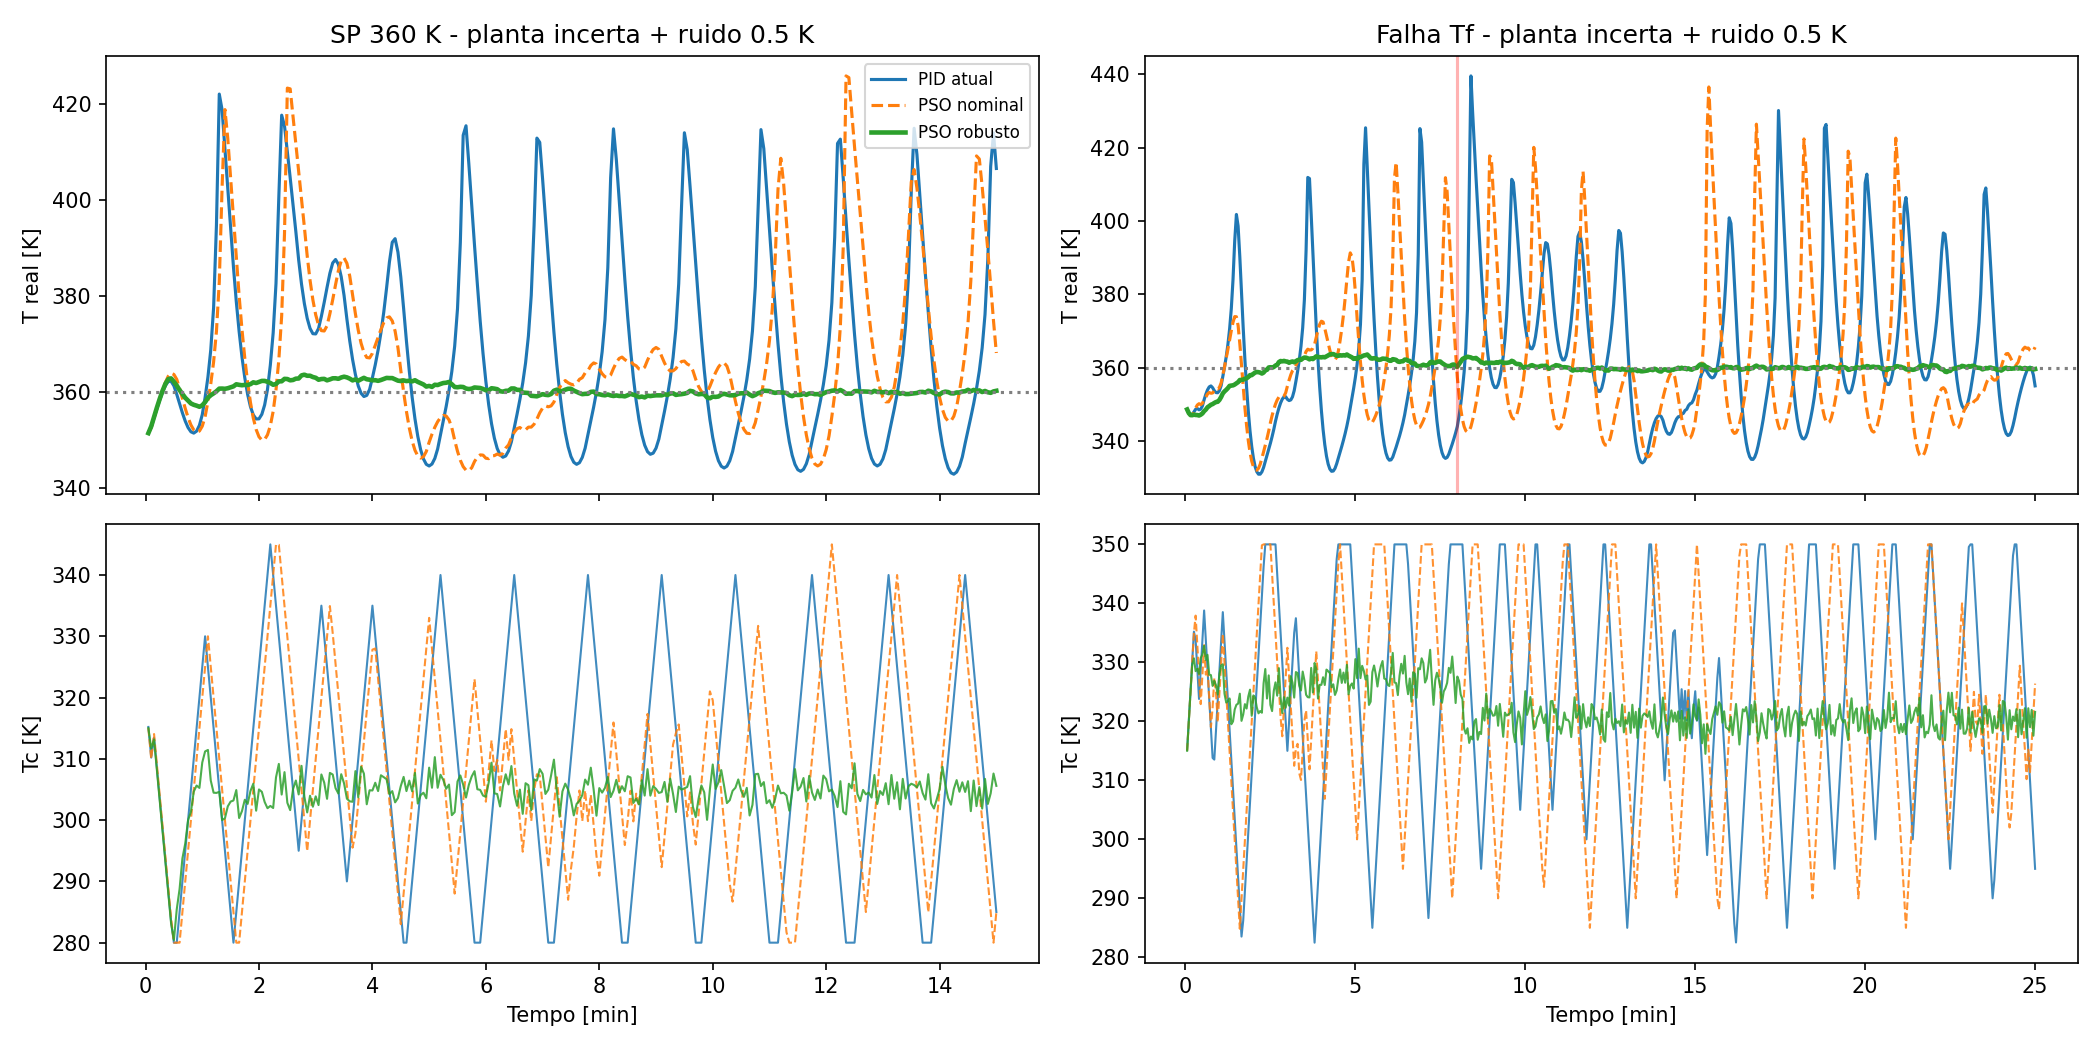

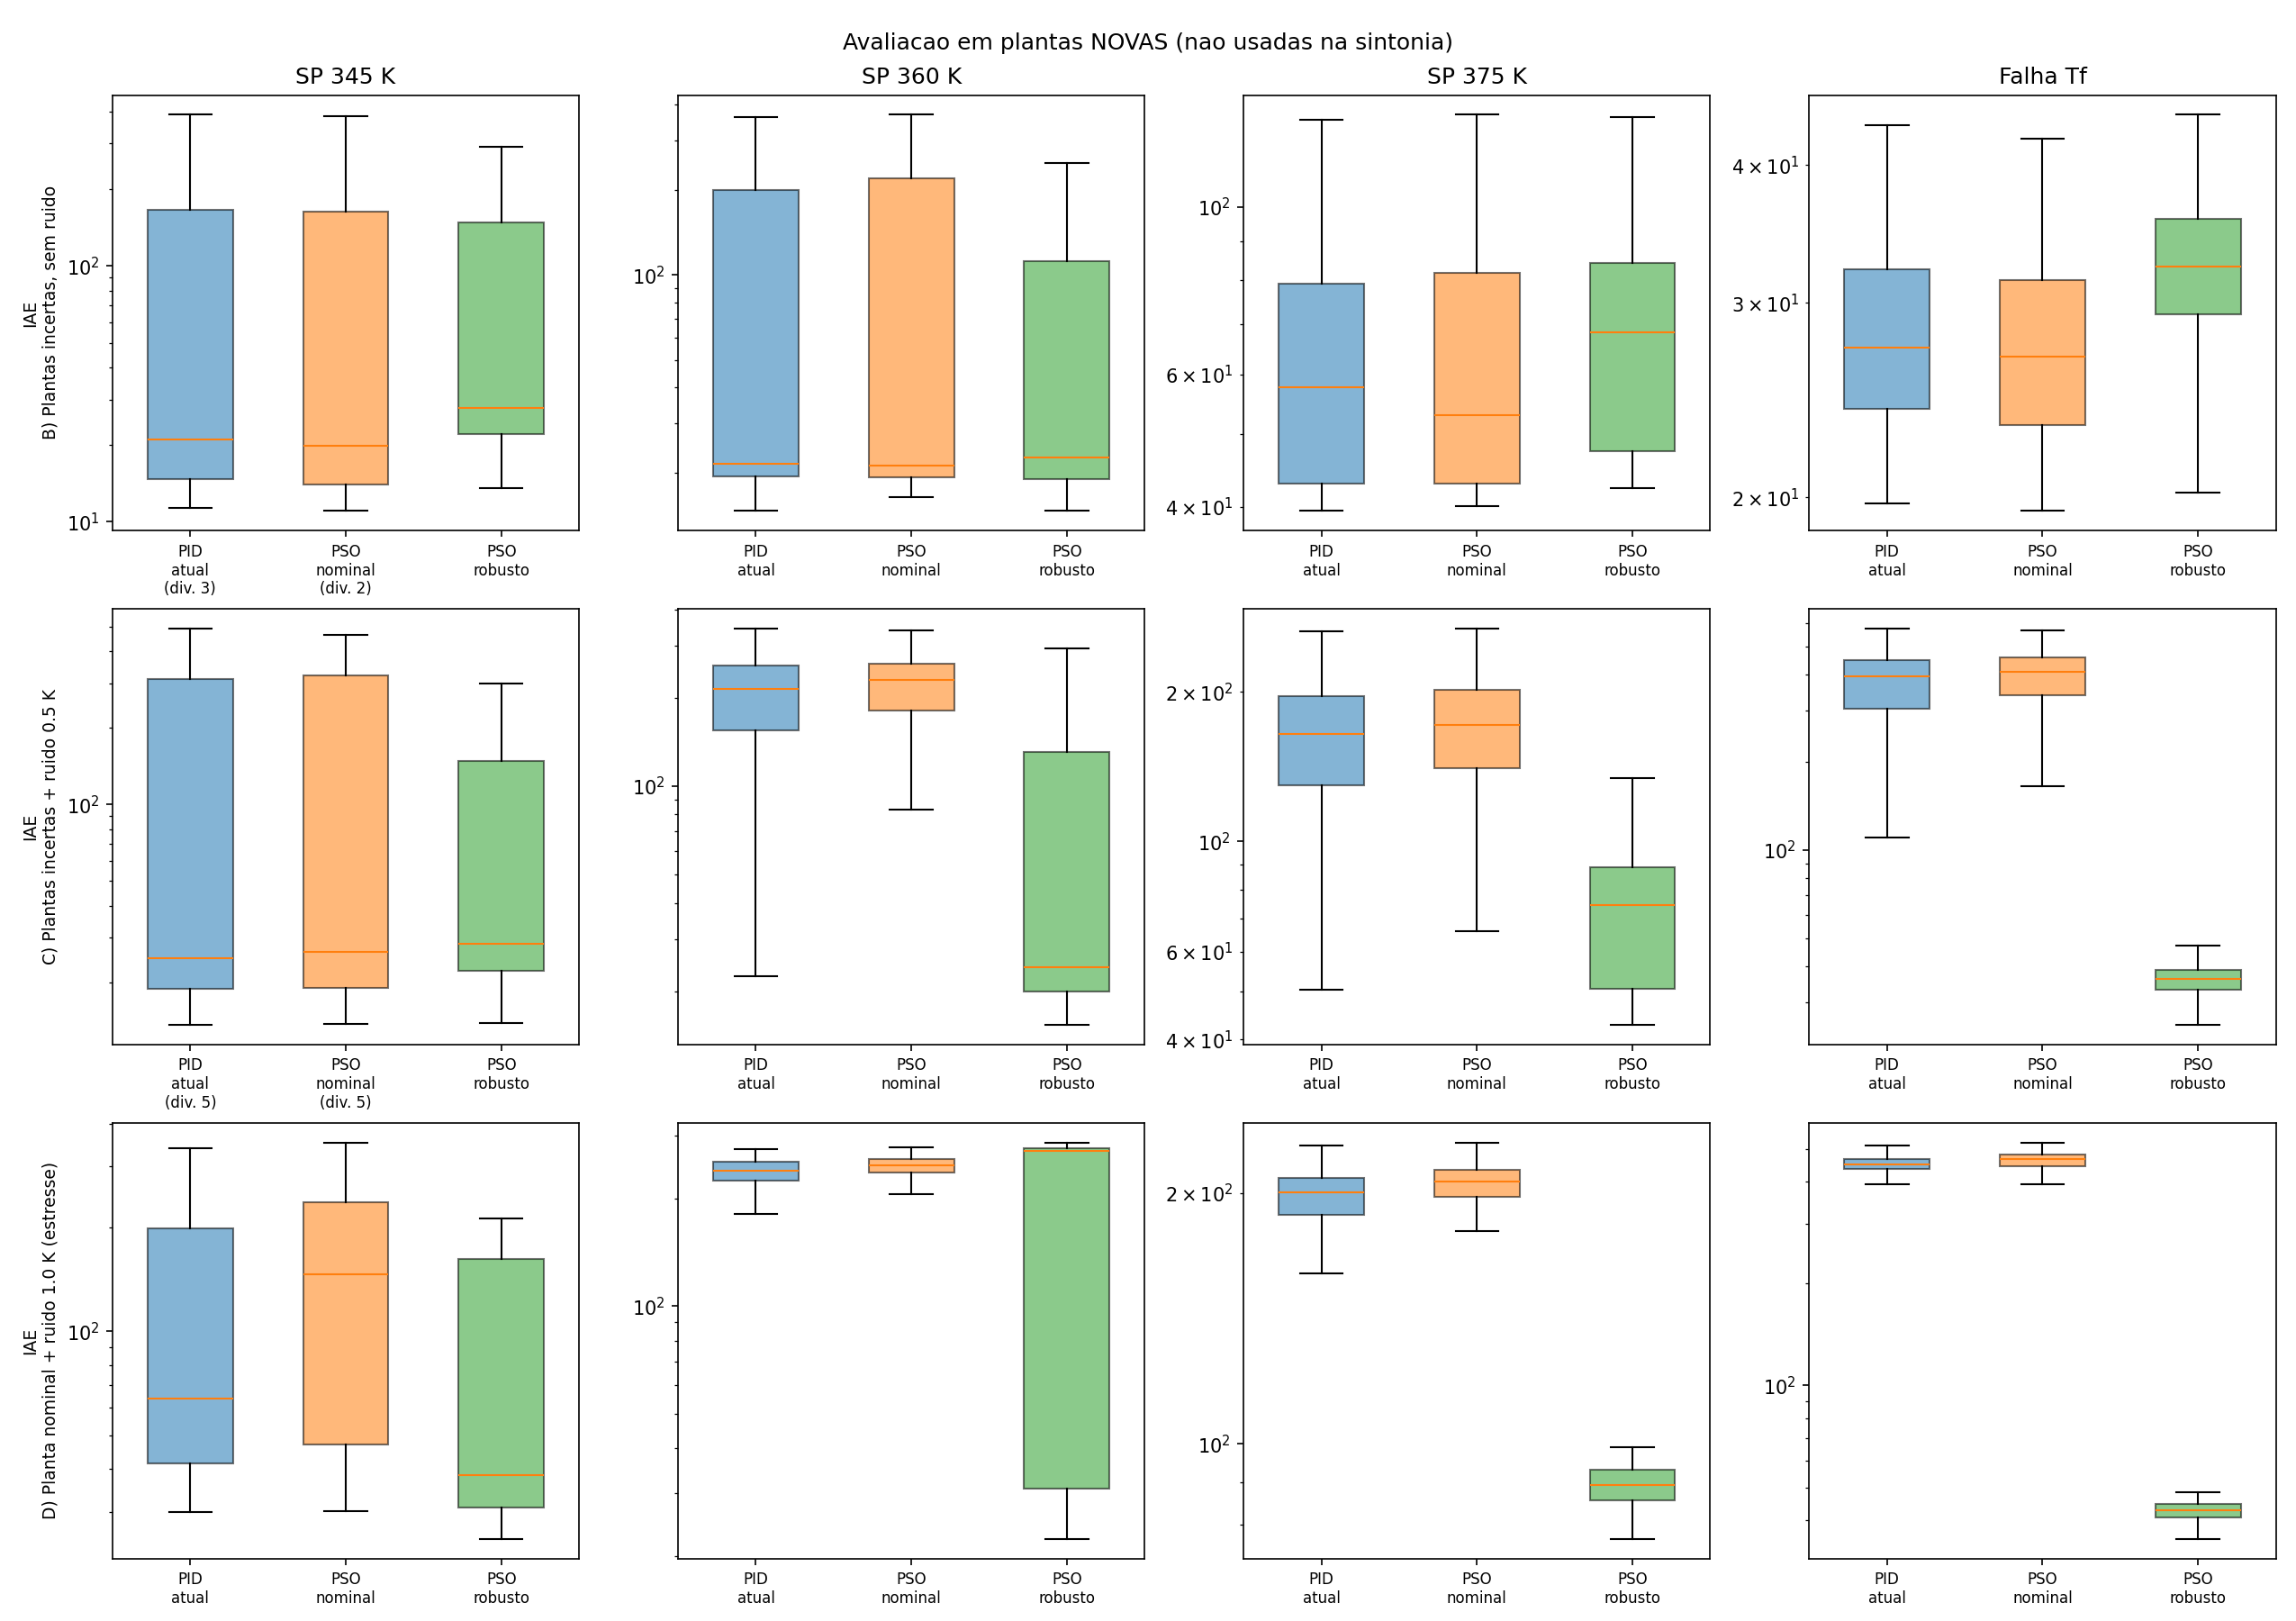

In [10]:
!python pso_robusto.py
display(Image('pso_robusto_respostas.png'))
display(Image('pso_robusto_montecarlo.png'))

## Conclusões

- **A sintonia no modelo nominal gera sobreajuste.** A melhoria de 7× no IAE em 360 K não sobrevive a erros de modelo de 5 %.
- **O problema real é o ruído amplificado pela derivada**, e não os ganhos em si.
- **O PSO robusto resolve o caso realista.** Com plantas incertas e ruído de 0,5 K, o IAE mediano cai de 214 para 24 (SP 360 K), de 164 para 75 (SP 375 K) e de 393 para 36 (falha em Tf). Ele é melhor que o PID de referência em 84–98 % das plantas nesses casos, sem nenhuma divergência.
- **O preço:** sem ruído ele fica um pouco pior (ex.: IAE 32 contra 27 na falha em Tf), e na planta nominal o overshoot em 375 K sobe de 10 para 49 K.

**Limitações:** é só simulação, com um modelo de livro-texto. Com a falha de concentração, nenhum PID evita o disparo térmico, porque o atuador satura (falta capacidade de resfriamento).